# Nepali Sentiment Classification Using BERT

### Dataset Used for Fine-Tuning: [NepaliSentiment](https://huggingface.co/datasets/Shushant/NepaliSentiment)

### Model Used for Fine-Tuning: [nepaliBERT](https://huggingface.co/Shushant/nepaliBERT)

## 1. Import required libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import torch
import mlflow
import numpy as np
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from huggingface_hub import HfApi
from huggingface_hub import notebook_login
from transformers.integrations import MLflowCallback
from datasets import load_dataset, concatenate_datasets
from optimum.onnxruntime import ORTModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from transformers import pipeline, Trainer, AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, DataCollatorWithPadding

## 2. Setup MLflow

In [3]:
# Define the MLflow tracking URI with SQLite
MLFLOW_TRACKING_URI = "sqlite:///mlflow.db"

# Set MLflow tracking URI
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)

In [4]:
# Set or create an experiment
mlflow.set_experiment("Nepali_Sentiment_Classification")

2025/11/20 17:14:45 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2025/11/20 17:14:45 INFO mlflow.store.db.utils: Updating database tables
2025-11-20 17:14:45 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-20 17:14:45 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.
2025-11-20 17:14:45 INFO  [alembic.runtime.migration] Context impl SQLiteImpl.
2025-11-20 17:14:45 INFO  [alembic.runtime.migration] Will assume non-transactional DDL.


<Experiment: artifact_location='/home/aashish/Amnil-AI-Internship/mlruns/1', creation_time=1763534127298, experiment_id='1', last_update_time=1763534127298, lifecycle_stage='active', name='Nepali_Sentiment_Classification', tags={'mlflow.experimentKind': 'custom_model_development'}>

## 3. Load Nepali Sentiment Dataset

In [5]:
nepali_sentiment = load_dataset("Shushant/NepaliSentiment")

In [6]:
nepali_sentiment

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 6000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 1996
    })
})

* train set - 6000 (75%)
* test set - 1996 (25%)

In [7]:
# Combine train and test sets
nepali_sentiment = concatenate_datasets([
    nepali_sentiment['train'], 
    nepali_sentiment['test']
])

# Shuffle and split the combined dataset with 95% train and 5% test
nepali_sentiment = nepali_sentiment.train_test_split(
    test_size=0.05,
    shuffle=True,
    seed=42            
)

In [8]:
nepali_sentiment

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 7596
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 400
    })
})

* train set - 7596 (95%)
* test set - 400 (5%)

In [9]:
nepali_sentiment['train']

Dataset({
    features: ['text', 'label'],
    num_rows: 7596
})

In [10]:
nepali_sentiment['test']

Dataset({
    features: ['text', 'label'],
    num_rows: 400
})

In [11]:
nepali_sentiment['train'][0]

{'text': 'यो हाम्रो समाजको जातीय बिभेदका कारण  धेरै मन दुखेर आउँछ । हामी मान्छेहरु किन पसुहरु भन्दा पनि असिक्छित भएका हौ । हामी कस्तो समाज मा बसेका छौ । यो समाज कहिले सिक्छित र सुधृन्छ होला।मेन कुरा त कानुन, शिक्षा र बिकास को कमिले होला । अब रबि सर यो जातीय बिभेदको बारेमा दरो खरो तरिकाले गाउँ टोल सहर सबै तिर तपाइको टिमले रिपोर्ट गरेर तपाइको आवज बाट असिक्छित मान्छे हरुलाइ सिक्छित बनाउने काम गर्नु होला',
 'label': '0'}

In [12]:
nepali_sentiment['test'][:3]

{'text': ['अन्तरजातीय बिवाह धेरै जसो सफल नहुनुमा।साना जातमा हुनेहरुको।आर्थिक स्थिति कमजोर हुनु पनि हो।किनकी हाम्रो समाजमा जातभात पछि अर्को कमजोरी आर्थिक सम्पन्नता को दृस्ठिकोण पनि हो।कतिपय परिवारले जातिए हिसाबले स्विकारे पनि आर्थिक हिसाबले स्विकार्न सक्दैनन।',
  'आहा धेरै खुसी लाग्यो रबि जि बोल्दा पनि मज्जा आउँछ , नियुज 24 को सिधा कुरा जनता सङ्ग हेर्नै मन लाग्दैन आजकाल।।',
  'रबि दादा हजुरको यहि साहासि पन ले नेपालिको मन जित्नु भएको छ ,आज खुशि लाग्यो फेरि हजुरको कार्यक्रम हेर्न पाउदा'],
 'label': ['0', '1', '1']}

## 4. Overview of Nepali Sentiment Dataset

In [13]:
nepali_sentiment.set_format('pandas')
df_train = nepali_sentiment['train'][:]
df_test = nepali_sentiment['test'][:]
df_train.sample(frac=1 , random_state=1).head(10)

,text,label
3072,दाइलाई दबाइ गर्नुको लागि पो टिकटकमा गिफ्टको ला...,0
927,अत्यन्तै राम्रो प्रस्तुति रबि सर।🙏🙏🙏🇳🇵🇳🇵🇳🇵🌺,0
6338,धन्यबाद अंकल सबै कलाकारको कुरा खोतलेर बाहिर लि...,1
420,Thank you so much #ghumante ..अर्को चोटि बाजुर...,1
863,ब्याटल पछि म टिम राजुबाट टिम प्रबिशामा छु । मल...,1
5036,पशु मन्त्रि भनेको सुन्न मन लाग्यो है मलाई नि 😄😄😄,0
3169,अबको दिनमा दलित कोटा होईन गरीब कोटा दिनु पर्छ ...,2
2927,👏🙏💐सिधा कुरा कार्यक्रम अब ट्रेन्डिङ १ मा लेराउ...,2
4049,नमस्कार रबि जि,1
6341,"हाम्रो नेता,मन्त्री हरु कुर्सी तानातान गर्दै ब...",0


In [14]:
df_train.loc[0, 'text']

'यो हाम्रो समाजको जातीय बिभेदका कारण  धेरै मन दुखेर आउँछ । हामी मान्छेहरु किन पसुहरु भन्दा पनि असिक्छित भएका हौ । हामी कस्तो समाज मा बसेका छौ । यो समाज कहिले सिक्छित र सुधृन्छ होला।मेन कुरा त कानुन, शिक्षा र बिकास को कमिले होला । अब रबि सर यो जातीय बिभेदको बारेमा दरो खरो तरिकाले गाउँ टोल सहर सबै तिर तपाइको टिमले रिपोर्ट गरेर तपाइको आवज बाट असिक्छित मान्छे हरुलाइ सिक्छित बनाउने काम गर्नु होला'

In [15]:
df_train.label.value_counts()

label
1     3107
0     2828
2     1650
-        6
o        2
11       1
--       1
20       1
Name: count, dtype: int64

In [16]:
df_train[df_train['label'] == '-']

,text,label
83,#Justisforchorimayamaharzan,-
652,जातिय बिभेद गर्नु पर्छ?,-
1289,बैदेशिक रोजगारीमा जाने दाजुभाइ दिदिबहिनीहरु सब...,-
1984,कुरा सुन्दा हासो र अनुहार हेर्दा मुटु त धुक ध...,-
3721,रबि सर 🇳🇵७:३५ मिनेट का लागि मात्रै अरुको लागि ...,-
7046,आझै हरेक न्याय नपायक जन्ता न्याय दिन सफल होस ...,-


In [17]:
df_train[df_train['label'] == '20']

,text,label
6286,उहाँ बाट नेपाल सप्रिने भन्दा बिग्रेर जान्छ।,20


In [18]:
df_train[df_train['label'] == '11']

,text,label
3964,लाखौं लाख सफलता को सुभकामना रबि सर,11


In [19]:
df_train[df_train['label'] == 'o']

,text,label
2783,रबि दाजु नमस्कार हजुरकाे हरेक कार्यक्रम नछुटाई...,o
3896,अन्याय मा परेका को मा मात्र नगई अन्याय गर्नेहर...,o


In [20]:
df_train[df_train['label'] == '--']

,text,label
4368,"साँचो अर्थमा अमेरिका एक आफैमा बिस्व हो, संसार ...",--


In [21]:
# 0 is negative
df_train[df_train['label'] == '0']

,text,label
0,यो हाम्रो समाजको जातीय बिभेदका कारण धेरै मन द...,0
2,म बारम्वार कमेण्टमा भन्ने गर्छु सरकारी सम्यन्त...,0
3,आम्म्दनी आठनी खर्च २ रूपेया भने को नेपाल मा य...,0
8,अब माओवादी रहेन समयमै काङ्ग्रेस तिर गाभ्नुस,0
9,थूक्क यस्ता खुराफाती खड्केको हलिहरु लाइ पनि ...,0
...,...,...
7575,थुक्क साला गाेरूहरू,0
7586,❤⬇ नत्र पाप लाग्छ नी ⬇❤❤,0
7589,MCC परतन्त्र चाहिदैन।,0
7590,मलाइ हजुरको whatsap वा imo नम्नर चाहियो,0


In [22]:
# 1 is neutral
df_train[df_train['label'] == '1']

,text,label
1,"जो स्वयं आफुलाई महान सम्झेर बसेको छ,",1
4,अरु कुरो थाहा भएन । हेम थापा दाई महान सच्चा ए...,1
5,बधाईछ सर सधै निरीह मानिसहरुकोअावाज बुलन्द पार...,1
6,घमण्ड भएर अगाडी बढनु भन्दा ज्ञानि भएर हार्नु न...,1
7,"जननेता, राजनेता तथा नेपाली राजनीतिको महानायक :...",1
...,...,...
7582,समाज परिवर्तनको लागि अहम भुमिका निभाउन सकोस हा...,1
7583,अति राम्रो कार्यकर्म,1
7591,हाम्रो देश उज्यालो राख्न सक्ने समाज सेबी रबि ल...,1
7593,finally मेरो जन्म भुमी को भिडियो लाई सबै नेपाल...,1


In [23]:
# 2 is positive
df_train[df_train['label'] == '2']

,text,label
15,20 घन्टा काम गर्नी अरे अनि लाइभमा मात्रा धेरै ...,2
19,छत्र लकाई खड्का,2
25,आयो आयो,2
36,"नेता रे बाउ चाइ, चुनाब नजिकै आउदेछ नेता ज्यु।",2
46,नेपालको चर्च र एनजिओ-आइएनजियोमा गैरदलित र गैरज...,2
...,...,...
7584,Uber ले जम्मा 12 घन्टा मत्र drive गर्न दिन्छ त...,2
7585,ब्याटल पछि LIVE ROUND मा प्रवेश गरेको छु । मला...,2
7587,"हौवा पत्रकार , भुमिकामा सम्पुर्ण पार्टीका जरो ...",2
7588,नारायण काजी अदक्ष भए ठिक हुन्छ,2


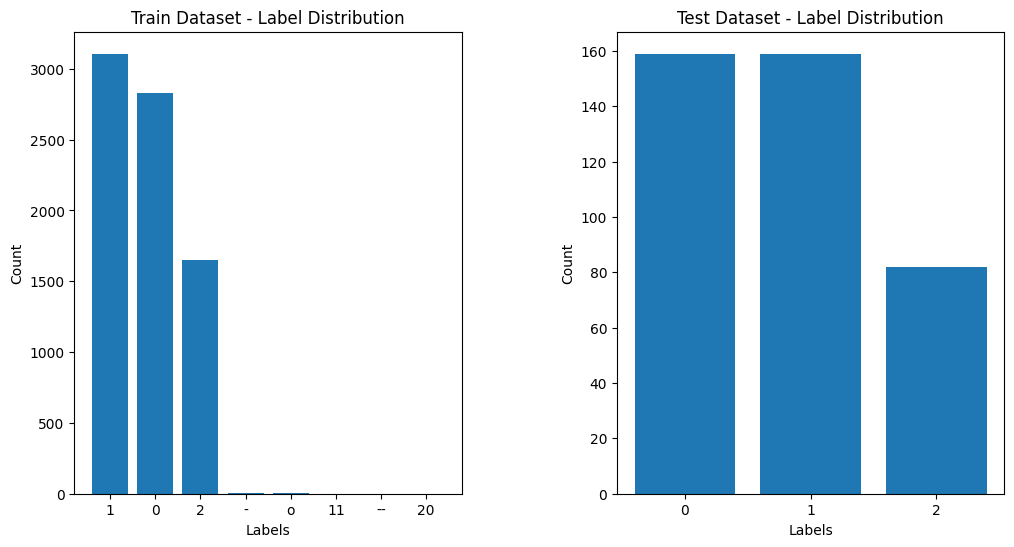

In [24]:
# Bar graph for train dataset
train_labels = df_train['label'].value_counts()

# Bar graph for test dataset
test_labels = df_test['label'].value_counts()

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Train dataset subplot
axs[0].bar(train_labels.index, train_labels.values)
axs[0].set_xlabel('Labels')
axs[0].set_ylabel('Count')
axs[0].set_title('Train Dataset - Label Distribution')

# Test dataset subplot
axs[1].bar(test_labels.index, test_labels.values)
axs[1].set_xlabel('Labels')
axs[1].set_ylabel('Count')
axs[1].set_title('Test Dataset - Label Distribution')

# Adjust spacing between subplots
plt.subplots_adjust(wspace=0.4)

# Display the plot
plt.show()

In [25]:
# Check for missing values in the train dataset
train_na = df_train.isna().sum()
print('Train Dataset - Missing Values:')
print(train_na)

test_na = df_test.isna().sum()
print('\nTest Dataset - Missing Values:')
print(test_na)

print("Train Dataset Size:",df_train.shape )
print("Test Dataset Size:", df_test.shape)

Train Dataset - Missing Values:
text     1
label    0
dtype: int64

Test Dataset - Missing Values:
text     1
label    0
dtype: int64
Train Dataset Size: (7596, 2)
Test Dataset Size: (400, 2)


In [26]:
nepali_sentiment.reset_format()

## 5. Data Preprocessing

In [27]:
# Training set labels before
print(Counter(nepali_sentiment['train']['label']))

Counter({'1': 3107, '0': 2828, '2': 1650, '-': 6, 'o': 2, '11': 1, '--': 1, '20': 1})


In [28]:
# Test set labels before
print(Counter(nepali_sentiment['test']['label']))

Counter({'0': 159, '1': 159, '2': 82})


In [29]:
# Filter the dataset
nepali_sentiment = nepali_sentiment.filter(lambda example: example['label'] in ['0', '1', '2'])

Filter:   0%|          | 0/7596 [00:00<?, ? examples/s]

Filter:   0%|          | 0/400 [00:00<?, ? examples/s]

In [30]:
nepali_sentiment

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 7585
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 400
    })
})

In [31]:
# Convert labels to integers
nepali_sentiment = nepali_sentiment.map(lambda example: {'label': int(example['label'])})

Map:   0%|          | 0/7585 [00:00<?, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

In [32]:
# Training set labels after
print(Counter(nepali_sentiment['train']['label']))

Counter({1: 3107, 0: 2828, 2: 1650})


In [33]:
# Test set labels after
print(Counter(nepali_sentiment['test']['label']))

Counter({0: 159, 1: 159, 2: 82})


In [34]:
# Define a filtering function
def filter_nans(example):
    # Check if 'text' or 'label' is None or NaN
    # For numerical columns, use math.isnan()
    # For string columns, check for None or empty strings
    is_text_nan = example['text'] is None or (isinstance(example['text'], float) and math.isnan(example['text']))
    is_label_nan = example['label'] is None or (isinstance(example['label'], float) and math.isnan(example['label']))
    
    # Return True if neither 'text' nor 'label' is NaN
    return not (is_text_nan or is_label_nan)

In [35]:
# Remove rows where "text" column is None or empty string
nepali_sentiment = nepali_sentiment.filter(filter_nans)

Filter:   0%|          | 0/7585 [00:00<?, ? examples/s]

Filter:   0%|          | 0/400 [00:00<?, ? examples/s]

## 6. Tokenizer

In [36]:
tokenizer = AutoTokenizer.from_pretrained("Shushant/nepaliBERT")
# tokenizer = AutoTokenizer.from_pretrained("distilbert/distilbert-base-multilingual-cased")
# tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-multilingual-uncased")

def tokenize_function(batch):
    return tokenizer(batch["text"], 
                     truncation=True, 
                     max_length=512)

nepali_sentiment_encoded = nepali_sentiment.map(tokenize_function, 
                                                batched=True, 
                                                batch_size=8)
nepali_sentiment_encoded

Map:   0%|          | 0/7584 [00:00<?, ? examples/s]

Map:   0%|          | 0/399 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 7584
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 399
    })
})

In [37]:
nepali_sentiment['train'][0]

{'text': 'यो हाम्रो समाजको जातीय बिभेदका कारण  धेरै मन दुखेर आउँछ । हामी मान्छेहरु किन पसुहरु भन्दा पनि असिक्छित भएका हौ । हामी कस्तो समाज मा बसेका छौ । यो समाज कहिले सिक्छित र सुधृन्छ होला।मेन कुरा त कानुन, शिक्षा र बिकास को कमिले होला । अब रबि सर यो जातीय बिभेदको बारेमा दरो खरो तरिकाले गाउँ टोल सहर सबै तिर तपाइको टिमले रिपोर्ट गरेर तपाइको आवज बाट असिक्छित मान्छे हरुलाइ सिक्छित बनाउने काम गर्नु होला',
 'label': 0}

In [38]:
nepali_sentiment_encoded['train'][0]

{'text': 'यो हाम्रो समाजको जातीय बिभेदका कारण  धेरै मन दुखेर आउँछ । हामी मान्छेहरु किन पसुहरु भन्दा पनि असिक्छित भएका हौ । हामी कस्तो समाज मा बसेका छौ । यो समाज कहिले सिक्छित र सुधृन्छ होला।मेन कुरा त कानुन, शिक्षा र बिकास को कमिले होला । अब रबि सर यो जातीय बिभेदको बारेमा दरो खरो तरिकाले गाउँ टोल सहर सबै तिर तपाइको टिमले रिपोर्ट गरेर तपाइको आवज बाट असिक्छित मान्छे हरुलाइ सिक्छित बनाउने काम गर्नु होला',
 'label': 0,
 'input_ids': [2,
  1786,
  1870,
  1857,
  5608,
  5932,
  1808,
  1048,
  1021,
  1677,
  2064,
  4555,
  2229,
  384,
  4006,
  16192,
  428,
  2166,
  2046,
  1054,
  1695,
  2466,
  4160,
  1695,
  8198,
  1743,
  1724,
  20754,
  1034,
  1780,
  1025,
  1955,
  6997,
  428,
  2166,
  2204,
  3090,
  2286,
  1723,
  28169,
  6030,
  428,
  1786,
  2286,
  4380,
  1024,
  5991,
  1780,
  1025,
  394,
  4052,
  1030,
  1054,
  2890,
  428,
  2229,
  7533,
  382,
  2453,
  1030,
  16,
  2037,
  1034,
  2592,
  394,
  7017,
  1805,
  4988,
  1024,
  2890,
  428,
  2227,
  1

* DataCollatorWithPadding creates batch of data. It also dynamically pads text to the length of the longest element in the batch, making them all the same length.

* It's possible to pad your text in the tokenizer function with padding=True, but dynamic padding is more efficient.

* Data Collator will pad data so that all examples are the same input length.
Attention mask is how we ignore attention scores for padding tokens

In [39]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

## 7. Model Training

In [40]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_labels = 3
nepali_bert = (AutoModelForSequenceClassification
         .from_pretrained("Shushant/nepaliBERT", num_labels=num_labels)
         .to(device))

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Shushant/nepaliBERT and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [41]:
nepali_bert.config.id2label = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
nepali_bert.config.label2id = {'Negative': 0, 'Neutral': 1, 'Positive': 2}

In [42]:
nepali_bert.config.id2label[0]

'Negative'

In [43]:
def compute_metrics(preds):
  predictions = preds.predictions.argmax(axis=-1)
  labels = preds.label_ids
  accuracy = accuracy_score(preds.label_ids, predictions)
  precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average="macro") 
  return {"accuracy": accuracy, "precision": precision, "recall": recall, "f1-score": f1}

In [44]:
batch_size = 8
epochs = 10

training_args = TrainingArguments(
    output_dir="./bert-finetuned-nepali-sentiment",
    num_train_epochs=epochs,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    load_best_model_at_end=True,
    optim='adamw_torch',
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=1,
    log_level='info',
    eval_strategy='epoch',
    save_strategy='epoch',
    metric_for_best_model="eval_f1-score",
    report_to=["mlflow"],
)

In [45]:
trainer = Trainer(
    model=nepali_bert,
    args=training_args,
    train_dataset=nepali_sentiment_encoded['train'],
    eval_dataset=nepali_sentiment_encoded['test'],
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    tokenizer=tokenizer
)

In [46]:
with mlflow.start_run(run_name="nepaliBERT_Fine_Tuning_Run") as run:
    mlflow.log_param("model_name", "nepaliBERT")
    mlflow.log_param("num_labels", 3)
    trainer.train()
    metrics = trainer.evaluate()
    mlflow.log_metrics(metrics)

The following columns in the Training set don't have a corresponding argument in `BertForSequenceClassification.forward` and have been ignored: text. If text are not expected by `BertForSequenceClassification.forward`,  you can safely ignore this message.
***** Running training *****
  Num examples = 7,584
  Num Epochs = 10
  Instantaneous batch size per device = 8
  Total train batch size (w. parallel, distributed & accumulation) = 8
  Gradient Accumulation steps = 1
  Total optimization steps = 9,480
  Number of trainable parameters = 109,484,547


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1-score
1,0.744100,0.608469,0.774436,0.765191,0.724384,0.733518
2,0.433000,0.749868,0.759398,0.737184,0.739047,0.736346
3,0.291400,0.989803,0.751880,0.728450,0.734700,0.729454
4,0.014700,1.013509,0.754386,0.730109,0.727099,0.728374
5,0.151100,1.173857,0.741855,0.718616,0.724385,0.720616
6,0.006400,1.370465,0.736842,0.717074,0.729969,0.720161
7,0.008100,1.399834,0.731830,0.711651,0.721813,0.713777
8,0.096800,1.420488,0.731830,0.710459,0.719937,0.713448
9,0.288100,1.534534,0.739348,0.717806,0.726226,0.720818
10,0.000400,1.649189,0.739348,0.716556,0.722302,0.718804


The following columns in the Evaluation set don't have a corresponding argument in `BertForSequenceClassification.forward` and have been ignored: text. If text are not expected by `BertForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 399
  Batch size = 8
Saving model checkpoint to ./bert-finetuned-nepali-sentiment/checkpoint-948
Configuration saved in ./bert-finetuned-nepali-sentiment/checkpoint-948/config.json
Model weights saved in ./bert-finetuned-nepali-sentiment/checkpoint-948/model.safetensors
tokenizer config file saved in ./bert-finetuned-nepali-sentiment/checkpoint-948/tokenizer_config.json
Special tokens file saved in ./bert-finetuned-nepali-sentiment/checkpoint-948/special_tokens_map.json
The following columns in the Evaluation set don't have a corresponding argument in `BertForSequenceClassification.forward` and have been ignored: text. If text are not expected by `BertForSequenceClassification.forward

The model overfit when training for 10 epochs. I had set the training arguments to load the `best model` at the end based on the `eval_f1-score`, so the `best model` with the highest `f1-score` of `0.736346` is one from epoch 2.

## 8. Model Evaluation

In [47]:
trainer.evaluate()

The following columns in the Evaluation set don't have a corresponding argument in `BertForSequenceClassification.forward` and have been ignored: text. If text are not expected by `BertForSequenceClassification.forward`,  you can safely ignore this message.

***** Running Evaluation *****
  Num examples = 399
  Batch size = 8


{'eval_loss': 0.749867856502533,
 'eval_accuracy': 0.7593984962406015,
 'eval_precision': 0.7371836297196009,
 'eval_recall': 0.7390471086463911,
 'eval_f1-score': 0.7363459365377486,
 'eval_runtime': 1.0163,
 'eval_samples_per_second': 392.61,
 'eval_steps_per_second': 49.199,
 'epoch': 10.0}

In [48]:
pipe = pipeline("text-classification", nepali_bert, tokenizer=tokenizer)
pipe("समाज बदल्ने र समाजमा एउटा नयां सकारात्मक सोच ल्याउने एउटै प्रश्न जातको प्रश्न 👏")

Device set to use cuda:0


[{'label': 'Neutral', 'score': 0.9886099100112915}]

In [49]:
pipe("जातीय विभेद दु:खद छ ! समाधान आफै भित्र खोजौ 🇳🇵🇳🇵🇳🇵")

[{'label': 'Negative', 'score': 0.9684140682220459}]

## 9. Model Saving

In [50]:
# Save model
trainer.save_model("./bert-finetuned-nepali-sentiment/model")

Saving model checkpoint to ./bert-finetuned-nepali-sentiment/model
Configuration saved in ./bert-finetuned-nepali-sentiment/model/config.json
Model weights saved in ./bert-finetuned-nepali-sentiment/model/model.safetensors
tokenizer config file saved in ./bert-finetuned-nepali-sentiment/model/tokenizer_config.json
Special tokens file saved in ./bert-finetuned-nepali-sentiment/model/special_tokens_map.json


In [51]:
# Save tokenizer
tokenizer.save_pretrained("./bert-finetuned-nepali-sentiment/tokenizer")

tokenizer config file saved in ./bert-finetuned-nepali-sentiment/tokenizer/tokenizer_config.json
Special tokens file saved in ./bert-finetuned-nepali-sentiment/tokenizer/special_tokens_map.json


('./bert-finetuned-nepali-sentiment/tokenizer/tokenizer_config.json',
 './bert-finetuned-nepali-sentiment/tokenizer/special_tokens_map.json',
 './bert-finetuned-nepali-sentiment/tokenizer/vocab.txt',
 './bert-finetuned-nepali-sentiment/tokenizer/added_tokens.json',
 './bert-finetuned-nepali-sentiment/tokenizer/tokenizer.json')

In [52]:
model_path = "./bert-finetuned-nepali-sentiment/model"
save_directory = "./bert-finetuned-nepali-sentiment/onnx_model"

# Load the fine-tuned model and tokenizer and Convert to ONNX
ort_model = ORTModelForSequenceClassification.from_pretrained(model_path, export=True)
tokenizer = AutoTokenizer.from_pretrained(model_path)

# Save the ONNX model and tokenizer
ort_model.save_pretrained(save_directory)
tokenizer.save_pretrained(save_directory)

loading configuration file ./bert-finetuned-nepali-sentiment/model/config.json
Model config PretrainedConfig {
  "architectures": [
    "BertForSequenceClassification"
  ],
  "attention_probs_dropout_prob": 0.1,
  "classifier_dropout": null,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "Negative",
    "1": "Neutral",
    "2": "Positive"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "label2id": {
    "Negative": 0,
    "Neutral": 1,
    "Positive": 2
  },
  "layer_norm_eps": 1e-12,
  "max_position_embeddings": 512,
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "position_embedding_type": "absolute",
  "problem_type": "single_label_classification",
  "transformers_version": "4.57.1",
  "type_vocab_size": 2,
  "use_cache": true,
  "vocab_size": 30522
}

loading configuration file ./bert-finetuned-nepali-sentiment/model/config.json
Model config BertConfig {
  "ar

('./bert-finetuned-nepali-sentiment/onnx_model/tokenizer_config.json',
 './bert-finetuned-nepali-sentiment/onnx_model/special_tokens_map.json',
 './bert-finetuned-nepali-sentiment/onnx_model/vocab.txt',
 './bert-finetuned-nepali-sentiment/onnx_model/added_tokens.json',
 './bert-finetuned-nepali-sentiment/onnx_model/tokenizer.json')

## 10. Share model on Hugging Face

In [53]:
notebook_login()

In [54]:
MODEL_IDENTIFIER = "aashish-mahato/nepalibert-sentiment-classifier"

In [55]:
# Push the model to Hugging Face
trainer.model.push_to_hub(
    repo_id=MODEL_IDENTIFIER,
    commit_message="Update model"
)

README.md: 0.00B [00:00, ?B/s]

Configuration saved in /tmp/tmpquj8r45v/config.json
Model weights saved in /tmp/tmpquj8r45v/model.safetensors
Uploading the following files to aashish-mahato/nepalibert-sentiment-classifier: README.md,model.safetensors,config.json


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/aashish-mahato/nepalibert-sentiment-classifier/commit/d724b14731aff72e2a176ef09092369a2596c423', commit_message='Update model', commit_description='', oid='d724b14731aff72e2a176ef09092369a2596c423', pr_url=None, repo_url=RepoUrl('https://huggingface.co/aashish-mahato/nepalibert-sentiment-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='aashish-mahato/nepalibert-sentiment-classifier'), pr_revision=None, pr_num=None)

In [56]:
# Push the tokenizer to Hugging Face
trainer.tokenizer.push_to_hub(
    repo_id=MODEL_IDENTIFIER, 
    commit_message="Update model"
)

Trainer.tokenizer is now deprecated. You should use Trainer.processing_class instead.
tokenizer config file saved in /tmp/tmp7zcrfmsn/tokenizer_config.json
Special tokens file saved in /tmp/tmp7zcrfmsn/special_tokens_map.json
Uploading the following files to aashish-mahato/nepalibert-sentiment-classifier: README.md,tokenizer.json,vocab.txt,special_tokens_map.json,tokenizer_config.json


CommitInfo(commit_url='https://huggingface.co/aashish-mahato/nepalibert-sentiment-classifier/commit/5fe850fd14a035815dfb2adf9611870c4aafdeb8', commit_message='Update model', commit_description='', oid='5fe850fd14a035815dfb2adf9611870c4aafdeb8', pr_url=None, repo_url=RepoUrl('https://huggingface.co/aashish-mahato/nepalibert-sentiment-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='aashish-mahato/nepalibert-sentiment-classifier'), pr_revision=None, pr_num=None)

In [57]:
# Push the ONNX model to Hugging Face
api = HfApi()

# Upload the model
api.upload_file(
    path_or_fileobj="./bert-finetuned-nepali-sentiment/onnx_model/model.onnx",
    path_in_repo="model.onnx",
    repo_id=MODEL_IDENTIFIER,
    commit_message="Update ONNX model"
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/aashish-mahato/nepalibert-sentiment-classifier/commit/2054df9c562ddd49322ef467a971a0ca912b590b', commit_message='Update ONNX model', commit_description='', oid='2054df9c562ddd49322ef467a971a0ca912b590b', pr_url=None, repo_url=RepoUrl('https://huggingface.co/aashish-mahato/nepalibert-sentiment-classifier', endpoint='https://huggingface.co', repo_type='model', repo_id='aashish-mahato/nepalibert-sentiment-classifier'), pr_revision=None, pr_num=None)